CPU times: user 34 s, sys: 19.9 s, total: 54 s
Wall time: 56.3 s


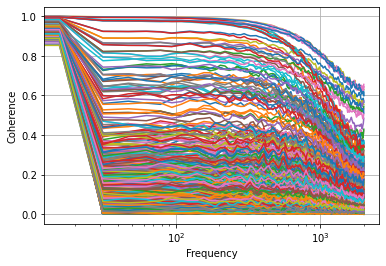

In [2]:
%%time
import sys, os
path_dir = os.getcwd()
sys.path.append(path_dir+"/Functions")
from General_functions import *
from Input_func import *
from IO_Plots import *
from PC_Plots import *
from DCN_Plots import *
from New_func import *
from Raster_hist_plots import *
from read_data import *
start_scope()
###################################################################
######################### Load Parameters #########################
###################################################################
# Name_BCM = "Learned_BCM"
# time_now_BCM = "09:15"
# Name_No_BCM = "No_BCM"
# time_now_No_BCM = "09:47"
# date = "06-07"
Name_BCM = "Learned_BCM"
time_now_BCM = "21:54"
Name_No_BCM = "No_BCM"
time_now_No_BCM = "15:10"
date = "06-10"
Frozen_data = sio.loadmat('Data/'+date+'/Frozen.mat', squeeze_me=True)
Params, Noise_frozen, Values, Synapses = Read_Input(Frozen_data)
###################################################################
############################ Load Data ############################
###################################################################
Output_Noise_No_BCM, Output_Noise_Extended_No_BCM, Output_PC_No_BCM, Output_DCN_No_BCM, Output_IO_No_BCM, Output_mon_N_PC_No_BCM, Output_Noise_Coupled_No_BCM, Output_Noise_Extended_Coupled_No_BCM, Output_PC_Coupled_No_BCM, Output_DCN_Coupled_No_BCM, Output_IO_Coupled_No_BCM, Output_mon_N_PC_Coupled = load_data(Name_No_BCM, time_now_No_BCM, date)
Output_Noise_BCM, Output_Noise_Extended_BCM, Output_PC_BCM, Output_DCN_BCM, Output_IO_BCM, Output_mon_N_PC_BCM, Output_Noise_Coupled_BCM, Output_Noise_Extended_Coupled_BCM, Output_PC_Coupled_BCM, Output_DCN_Coupled_BCM, Output_IO_Coupled_BCM, Output_mon_N_PC_Coupled = load_data(Name_BCM, time_now_BCM, date)
###################################################################
########################### Load Cells ############################
###################################################################
Noise_BCM, Noise_Extended_BCM, PC_BCM, DCN_BCM, IO_BCM, mon_N_PC_BCM = Output_func(Name_BCM,"",Output_Noise_BCM, Output_Noise_Extended_BCM, Output_PC_BCM, Output_DCN_BCM, Output_IO_BCM, Output_mon_N_PC_BCM, Output_Noise_Coupled_BCM, Output_Noise_Extended_Coupled_BCM, Output_PC_Coupled_BCM, Output_DCN_Coupled_BCM, Output_IO_Coupled_BCM, Output_mon_N_PC_Coupled)
Noise_Coupled_BCM, Noise_Extended_Coupled_BCM, PC_Coupled_BCM, DCN_Coupled_BCM, IO_Coupled_BCM, mon_N_PC_Coupled_BCM = Output_func(Name_BCM,"Coupled",Output_Noise_BCM, Output_Noise_Extended_BCM, Output_PC_BCM, Output_DCN_BCM, Output_IO_BCM, Output_mon_N_PC_BCM, Output_Noise_Coupled_BCM, Output_Noise_Extended_Coupled_BCM, Output_PC_Coupled_BCM, Output_DCN_Coupled_BCM, Output_IO_Coupled_BCM, Output_mon_N_PC_Coupled)
time_x_BCM = Noise_BCM.t

Noise_No_BCM, Noise_Extended_No_BCM, PC_No_BCM, DCN_No_BCM, IO_No_BCM, mon_N_PC_No_BCM = Output_func(Name_No_BCM,"",Output_Noise_No_BCM, Output_Noise_Extended_No_BCM, Output_PC_No_BCM, Output_DCN_No_BCM, Output_IO_No_BCM, Output_mon_N_PC_No_BCM, Output_Noise_Coupled_No_BCM, Output_Noise_Extended_Coupled_No_BCM, Output_PC_Coupled_No_BCM, Output_DCN_Coupled_No_BCM, Output_IO_Coupled_No_BCM, Output_mon_N_PC_Coupled)
Noise_Coupled_No_BCM, Noise_Extended_Coupled_No_BCM, PC_Coupled_No_BCM, DCN_Coupled_No_BCM, IO_Coupled_No_BCM, mon_N_PC_Coupled_No_BCM = Output_func(Name_No_BCM,"Coupled",Output_Noise_No_BCM, Output_Noise_Extended_No_BCM, Output_PC_No_BCM, Output_DCN_No_BCM, Output_IO_No_BCM, Output_mon_N_PC_No_BCM, Output_Noise_Coupled_No_BCM, Output_Noise_Extended_Coupled_No_BCM, Output_PC_Coupled_No_BCM, Output_DCN_Coupled_No_BCM, Output_IO_Coupled_No_BCM, Output_mon_N_PC_Coupled)
time_x_No_BCM = Noise_No_BCM.t

step1 = 550
step = int(step1/(Params.dt_rec/msecond))
xx = range(-step,step)
xx1 = [item * (Params.dt_rec/msecond) for item in xx]
half = int(time_x_BCM[len(time_x_BCM)//2]/1000)

f_No_BCM = [[]]*Params.N_Cells_PC
f_During_BCM = [[]]*Params.N_Cells_PC
f_BCM = [[]]*Params.N_Cells_PC
f_Coupled_No_BCM = [[]]*Params.N_Cells_PC
f_Coupled_During_BCM = [[]]*Params.N_Cells_PC
f_Coupled_BCM = [[]]*Params.N_Cells_PC
cxy_No_BCM = [[]]*Params.N_Cells_PC
cxy_During_BCM = [[]]*Params.N_Cells_PC
cxy_BCM = [[]]*Params.N_Cells_PC
cxy_Coupled_No_BCM = [[]]*Params.N_Cells_PC
cxy_Coupled_During_BCM = [[]]*Params.N_Cells_PC
cxy_Coupled_BCM = [[]]*Params.N_Cells_PC
for ii in range(0,Params.N_Cells_PC):
    f_No_BCM[ii] = [[]]*Params.N_Noise
    f_During_BCM[ii] = [[]]*Params.N_Noise
    f_BCM[ii] = [[]]*Params.N_Noise
    f_Coupled_No_BCM[ii] = [[]]*Params.N_Noise
    f_Coupled_During_BCM[ii] = [[]]*Params.N_Noise
    f_Coupled_BCM[ii] = [[]]*Params.N_Noise
    cxy_No_BCM[ii] = [[]]*Params.N_Noise
    cxy_During_BCM[ii] = [[]]*Params.N_Noise
    cxy_BCM[ii] = [[]]*Params.N_Noise
    cxy_Coupled_No_BCM[ii] = [[]]*Params.N_Noise
    cxy_Coupled_During_BCM[ii] = [[]]*Params.N_Noise
    cxy_Coupled_BCM[ii] = [[]]*Params.N_Noise
    for jj in range(0,Params.N_Noise):     
        cxy_No_BCM[ii][jj], f_No_BCM[ii][jj] = cohere(PC_No_BCM.I_Noise[ii]/nA, Noise_No_BCM.I[jj]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_During_BCM[ii][jj], f_During_BCM[ii][jj] = cohere(PC_BCM.I_Noise[ii][:len(PC_BCM.I_Noise[ii])//2]/nA, Noise_Extended_BCM.I[jj][:len(Noise_Extended_BCM.I[jj])//2]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_BCM[ii][jj], f_BCM[ii][jj] = cohere(PC_BCM.I_Noise[ii][len(PC_BCM.I_Noise[ii])//2:]/nA, Noise_Extended_BCM.I[jj][len(Noise_Extended_BCM.I[jj])//2:]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_Coupled_No_BCM[ii][jj], f_Coupled_No_BCM[ii][jj] = cohere(PC_Coupled_No_BCM.I_Noise[ii]/nA, Noise_Coupled_No_BCM.I[jj]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_Coupled_During_BCM[ii][jj], f_Coupled_During_BCM[ii][jj] = cohere(PC_Coupled_BCM.I_Noise[ii][:len(PC_Coupled_BCM.I_Noise[ii])//2]/nA, Noise_Extended_Coupled_BCM.I[jj][:len(Noise_Extended_Coupled_BCM.I[jj])//2]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
        cxy_Coupled_BCM[ii][jj], f_Coupled_BCM[ii][jj] = cohere(PC_Coupled_BCM.I_Noise[ii][len(PC_Coupled_BCM.I_Noise[ii])//2:]/nA, Noise_Extended_Coupled_BCM.I[jj][len(Noise_Extended_Coupled_BCM.I[jj])//2:]/nA, 256, 1./Params.dt_rec/second ,label="Noise "+str(jj+1))
    xscale('log')
    
mean_point_cxy_No_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_During_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_Coupled_No_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_Coupled_During_BCM = [[]]*Params.N_Cells_PC
mean_point_cxy_Coupled_BCM = [[]]*Params.N_Cells_PC
for ii in range(0,Params.N_Cells_PC):
    mean_point_cxy_No_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_During_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_Coupled_No_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_Coupled_During_BCM[ii] = [[]]*Params.N_Noise
    mean_point_cxy_Coupled_BCM[ii] = [[]]*Params.N_Noise
    for jj in range(0,Params.N_Noise):
        idx_aa = []
        for kk in range(0,len(f_No_BCM[ii][jj])):
            if 10**2 <= f_No_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_No_BCM[ii][jj] = mean(cxy_No_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_During_BCM[ii][jj])):
            if 10**2 <= f_During_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_During_BCM[ii][jj] = mean(cxy_During_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_BCM[ii][jj])):
            if 10**2 <= f_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_BCM[ii][jj] = mean(cxy_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_Coupled_No_BCM[ii][jj])):
            if 10**2 <= f_Coupled_No_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_Coupled_No_BCM[ii][jj] = mean(cxy_Coupled_No_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_Coupled_During_BCM[ii][jj])):
            if 10**2 <= f_Coupled_During_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_Coupled_During_BCM[ii][jj] = mean(cxy_Coupled_During_BCM[ii][jj][idx_aa])
        idx_aa = []
        for kk in range(0,len(f_Coupled_BCM[ii][jj])):
            if 10**2 <= f_Coupled_BCM[ii][jj][kk]/Hz/Hz <= 10**3:
                idx_aa.append(kk)
        mean_point_cxy_Coupled_BCM[ii][jj] = mean(cxy_Coupled_BCM[ii][jj][idx_aa])
        

Text(0.5, 1.0, 'Before and after BCM firing frequencies PC (Coupled)')

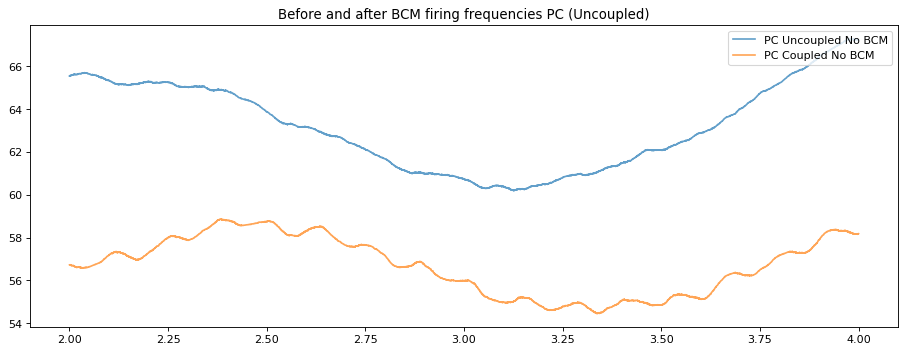

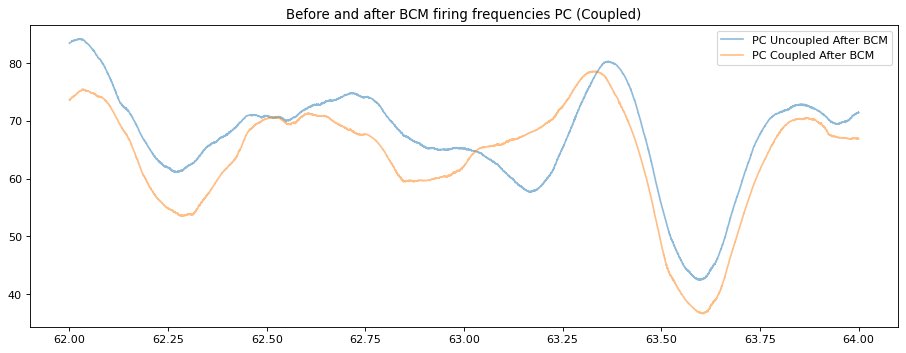

In [8]:
start = int(2/Params.dt)
end = int(4/Params.dt)
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
plot(PC_No_BCM.rate_time[start:end]/1000,PC_No_BCM.rate[start:end], label='PC Uncoupled No BCM', alpha=0.7)
plot(PC_No_BCM.rate_time[start:end]/1000,PC_Coupled_No_BCM.rate[start:end], label='PC Coupled No BCM', alpha=0.7)
legend(loc='upper right')
title('Before and after BCM firing frequencies PC (Uncoupled)')

start = int(62/Params.dt)
end = int(64/Params.dt)
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
plot(PC_No_BCM.rate_time[start:end]/1000,PC_BCM.rate[start:end], label='PC Uncoupled After BCM', alpha=0.5)
plot(PC_No_BCM.rate_time[start:end]/1000,PC_Coupled_BCM.rate[start:end], label='PC Coupled After BCM', alpha=0.5)
legend(loc='upper right')
title('Before and after BCM firing frequencies PC (Coupled)')

Text(0.5, 1.0, 'Before and after BCM firing frequencies PC (Coupled)')

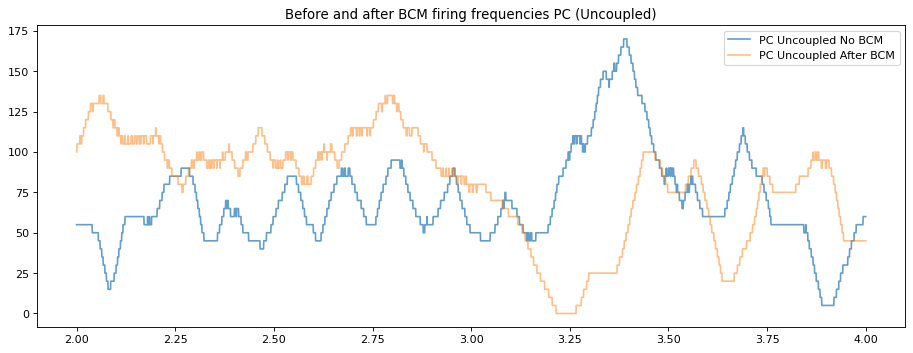

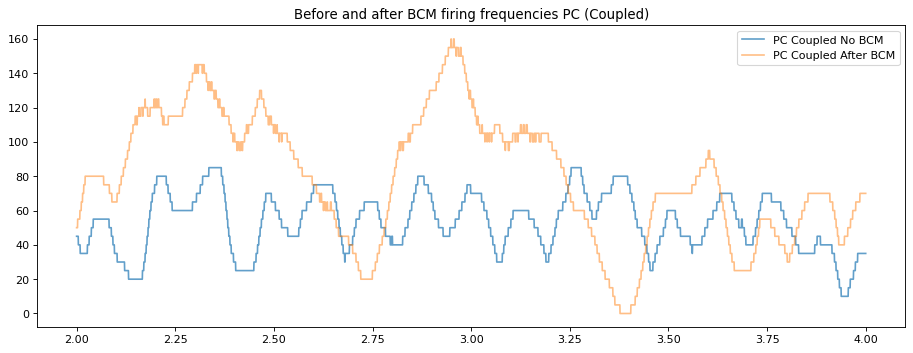

In [63]:
start = int(2/Params.dt_rec)
end = int(4/Params.dt_rec)
start1 = int(60/Params.dt_rec)+start
end1 = int(60/Params.dt_rec)+end
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
plot(time_x_No_BCM[start:end]/1000,PC_No_BCM.recent_rate[0][start:end], label='PC Uncoupled No BCM', alpha=0.7)
plot(time_x_No_BCM[start:end]/1000,PC_BCM.recent_rate[0][start1:end1], label='PC Uncoupled After BCM', alpha=0.5)
legend(loc='upper right')
title('Before and after BCM firing frequencies PC (Uncoupled)')


plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
plot(time_x_No_BCM[start:end]/1000,PC_Coupled_No_BCM.recent_rate[0][start:end], label='PC Coupled No BCM', alpha=0.7)
plot(time_x_No_BCM[start:end]/1000,PC_Coupled_BCM.recent_rate[0][start1:end1], label='PC Coupled After BCM', alpha=0.5)
legend(loc='upper right')
title('Before and after BCM firing frequencies PC (Coupled)')

In [64]:
arr1 = PC_No_BCM.recent_rate[0][start:end]
arr2 = PC_BCM.recent_rate[0][start1:end1]
aa = numpy.correlate(arr1,arr2,"full")

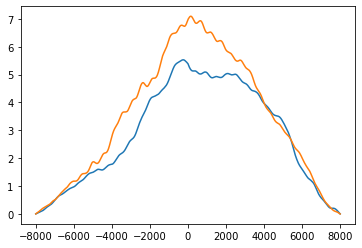

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate

def plot_xcorr(x, y): 
    "Plot cross-correlation (full) between two signals."
    N = max(len(x), len(y)) 
    n = min(len(x), len(y)) 

    if N == len(y): 
        lags = np.arange(-N + 1, n) 
    else: 
        lags = np.arange(-n + 1, N) 
    c = correlate(x / std(x), y / std(y), 'full') 

    plt.plot(lags, c / n) 
#     plt.show() 

arr1 = PC_No_BCM.recent_rate[0][start:end]
arr2 = PC_BCM.recent_rate[0][start1:end1]
aa = numpy.correlate(arr1,arr2,"full")
plot_xcorr(arr1,arr2)
arr1 = PC_Coupled_No_BCM.recent_rate[0][start:end]
arr2 = PC_Coupled_BCM.recent_rate[0][start1:end1]
aa = numpy.correlate(arr1,arr2,"full")
plot_xcorr(arr1,arr2)
# xlim([-int(1/Params.dt_rec*second),int(1/Params.dt*second)])

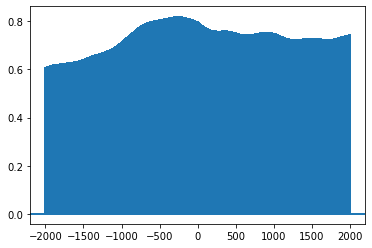

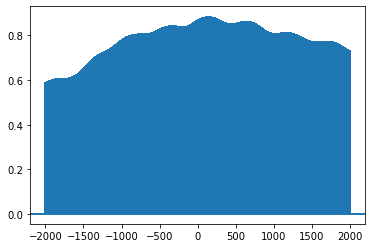

In [68]:
arr1 = PC_No_BCM.recent_rate[0][start:end]
arr2 = PC_BCM.recent_rate[0][start1:end1]
plt.xcorr(arr1,arr2, usevlines=True, maxlags=2000, normed=True, lw=2)
plt.show()
arr1 = PC_Coupled_No_BCM.recent_rate[0][start:end]
arr2 = PC_Coupled_BCM.recent_rate[0][start1:end1]
plt.xcorr(arr1,arr2, usevlines=True, maxlags=2000, normed=True, lw=2)
plt.show()

In [42]:
int(0.5/Params.dt_rec*second)

2000

In [73]:
def xcorr(x, y, scale='none'):
    # Pad shorter array if signals are different lengths
    if x.size > y.size:
        pad_amount = x.size - y.size
        y = np.append(y, np.repeat(0, pad_amount))
    elif y.size > x.size:
        pad_amount = y.size - x.size
        x = np.append(x, np.repeat(0, pad_amount))

    corr = np.correlate(x, y, mode='full')  # scale = 'none'
    lags = np.arange(-(x.size - 1), x.size)

    if scale == 'biased':
        corr = corr / x.size
    elif scale == 'unbiased':
        corr /= (x.size - abs(lags))
    elif scale == 'coeff':
        corr /= np.sqrt(np.dot(x, x) * np.dot(y, y))
    return corr

In [74]:
a = xcorr(arr1, arr2, scale='unbiased')

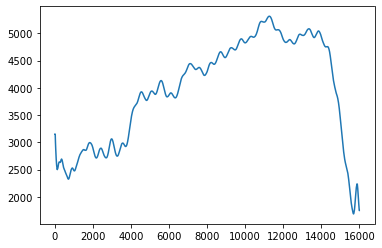

In [76]:
plot(a)

Text(0.5, 1.0, 'Before and after BCM firing frequencies PC (Coupled)')

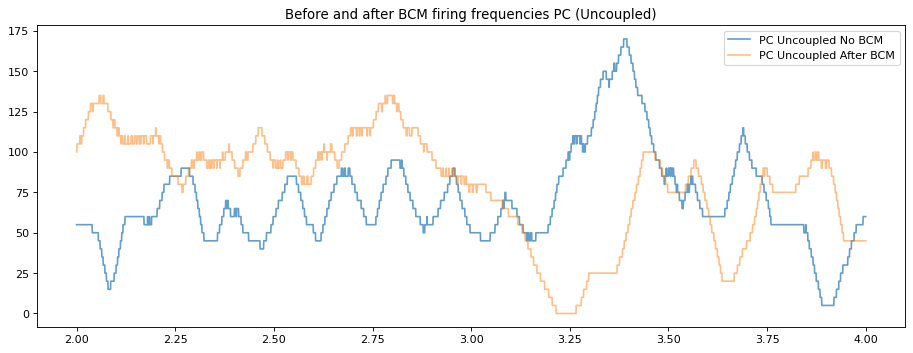

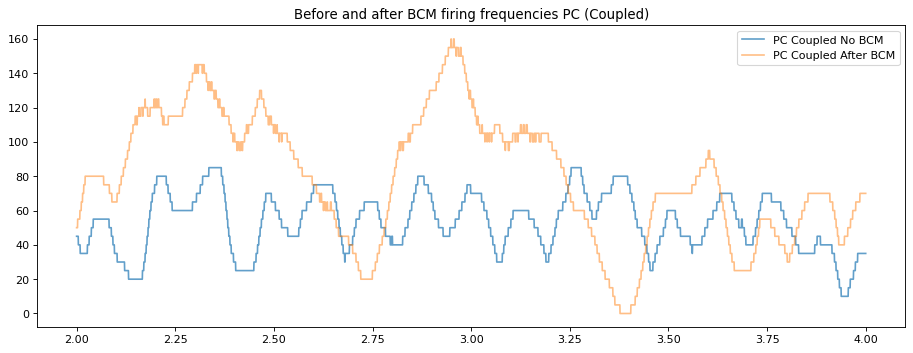